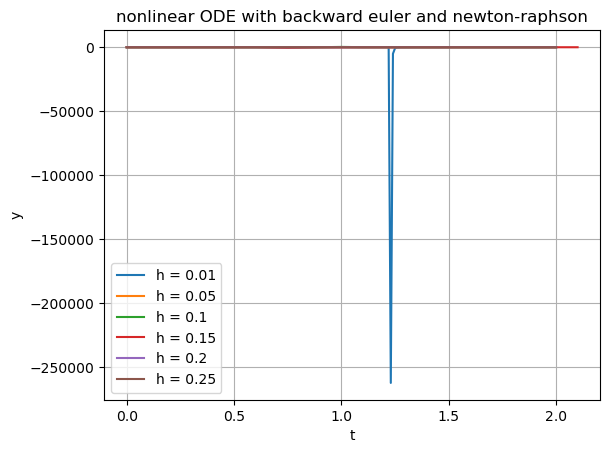

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import math
import time

def f_nonlinear(t, y):
    return y**2 - 2
 
# newton-raphson to solve g(y_next) = 0
def newton_raphson(g, g_prime, y_prev, tol=1e-6, max_iter=100):
    y = y_prev
    for i in range(max_iter):
        y_new = y - g(y) / g_prime(y)
        if abs(y_new - y) < tol:
            return y_new
        y = y_new
    return y
 
# backward euler with newton-raphson
def backward_euler_newton(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0
 
    for i in range(1, len(t_values)):
        t_next = t_values[i]
        y_prev = y_values[i - 1]
 
        g = lambda y_next: y_next - y_prev - h * f(t_next, y_next)
        g_prime = lambda y_next: 1 - h * 2 * y_next
 
        y_values[i] = newton_raphson(g, g_prime, y_prev)
 
    return t_values, y_values
 
y0 = 1.5
t0 = 0
tf = 2
h_values = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25]
 
plt.figure()
 
for h in h_values:
    t_values_nl, y_values_nl = backward_euler_newton(f_nonlinear, y0, t0, tf, h)
    plt.plot(t_values_nl, y_values_nl, label=f"h = {h}")
 
plt.xlabel("t")
plt.ylabel("y")
plt.title("nonlinear ODE with backward euler and newton-raphson")
plt.legend()
plt.grid(True)
plt.show()
